# 📊 Customer Sales Analysis Dashboard

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
df = pd.read_csv('customer_sales_data.csv')
print("First 5 Records")
print(df.head())

First 5 Records
  Customer_ID  Gender  Age Region Product_Category  Units_Purchased  \
0    CUST0118    Male   20  South        Groceries                1   
1    CUST0096    Male   62  South        Groceries                1   
2    CUST0005  Female   32   East            Books                2   
3    CUST0094    Male   60   West        Groceries                3   
4    CUST0110  Female   61   West        Groceries                1   

   Price_Per_Unit Purchase_Date  Total_Amount  
0           65.26    13-02-2024         65.26  
1          112.59    20-07-2024        112.59  
2           80.22    25-06-2024        160.44  
3           56.33    15-06-2024        168.99  
4          172.53    01-01-2024        172.53  


In [3]:
print(df.columns)
print(df.dtypes)
print(df.shape)

Index(['Customer_ID', 'Gender', 'Age', 'Region', 'Product_Category',
       'Units_Purchased', 'Price_Per_Unit', 'Purchase_Date', 'Total_Amount'],
      dtype='str')
Customer_ID             str
Gender                  str
Age                   int64
Region                  str
Product_Category        str
Units_Purchased       int64
Price_Per_Unit      float64
Purchase_Date           str
Total_Amount        float64
dtype: object
(150, 9)


In [4]:
df['Purchase_Date'] = pd.to_datetime(df['Purchase_Date'] , format='mixed' , dayfirst=True)
print(df.isnull().sum())
print(df.duplicated().sum())
df.drop_duplicates(inplace=True)


Customer_ID         0
Gender              0
Age                 0
Region              0
Product_Category    0
Units_Purchased     0
Price_Per_Unit      0
Purchase_Date       0
Total_Amount        0
dtype: int64
0


In [5]:
df['Month'] = df['Purchase_Date'].dt.month_name()

df['Month_Number'] = df['Purchase_Date'].dt.month

df['Week'] = df['Purchase_Date'].dt.isocalendar().week

df['Day'] = df['Purchase_Date'].dt.day_name()

df['Year'] = df['Purchase_Date'].dt.year

print(df)

    Customer_ID  Gender  Age Region Product_Category  Units_Purchased  \
0      CUST0118    Male   20  South        Groceries                1   
1      CUST0096    Male   62  South        Groceries                1   
2      CUST0005  Female   32   East            Books                2   
3      CUST0094    Male   60   West        Groceries                3   
4      CUST0110  Female   61   West        Groceries                1   
..          ...     ...  ...    ...              ...              ...   
145    CUST0071  Female   43  South      Electronics                5   
146    CUST0111  Female   42  North      Electronics                5   
147    CUST0077    Male   64   East      Electronics                4   
148    CUST0082    Male   40   East      Electronics                5   
149    CUST0039  Female   20  South      Electronics                5   

     Price_Per_Unit Purchase_Date  Total_Amount     Month  Month_Number  Week  \
0             65.26    2024-02-13         

In [6]:
sales = np.array(df['Total_Amount'])

units = np.array(df['Units_Purchased'])

print(np.mean(sales))

print(df['Total_Amount'].mean())
print(np.array(df['Total_Amount']).mean())
print(np.median(sales))
print(np.max(sales))

1595.198
1595.198
1595.198
1238.705
6220.4


# Sales by Gender

In [9]:
gender_sales = df.groupby("Gender")["Total_Amount"].sum()

print(gender_sales)

Gender
Female    116884.88
Male      122394.82
Name: Total_Amount, dtype: float64


# Sales by Region

In [10]:
region_sales = df.groupby("Region")["Total_Amount"].sum()

print(region_sales)

Region
East     66477.17
North    61724.64
South    63702.95
West     47374.94
Name: Total_Amount, dtype: float64


# Sales by Product Categories

In [11]:
product_sales = df.groupby("Product_Category")["Total_Amount"].sum()

print(product_sales)

Product_Category
Books          22956.41
Clothing       40342.40
Electronics    80871.19
Groceries      17596.91
Sports         77512.79
Name: Total_Amount, dtype: float64


# Month-wise

In [18]:
monthly_sales = df.groupby(df["Purchase_Date"].dt.month_name())["Total_Amount"].sum().reindex(["January" , "February"])

print(monthly_sales)

Purchase_Date
January     20951.81
February    15121.24
Name: Total_Amount, dtype: float64


# Weekly Sales

In [19]:
weekly_sales = df.groupby(df["Purchase_Date"].dt.isocalendar().week)["Total_Amount"].sum()

print(weekly_sales)

week
1      6912.48
2      8750.56
3      4704.90
4      1436.94
5       723.33
6      5924.86
7       538.32
8      3548.86
9      6153.48
10     2586.38
11     7044.65
12     4254.08
13     1684.12
14      538.15
15     6529.60
16      881.02
17     3395.80
18     7975.42
19     3533.47
20     4224.04
21    16370.74
22     4125.92
23     2822.36
24     9466.06
25    11652.41
26     4742.48
27     5014.24
28     7342.54
29     1073.67
30     1287.20
31     9531.34
32     8355.88
33     6409.86
34     2248.14
35     3904.45
36     2210.42
37     5268.60
38     2429.20
39     2157.33
40     1280.68
41     5422.05
42     2845.50
43     2844.34
44     2661.14
45      652.80
46     8327.32
47      323.89
48     2489.27
49    10665.72
50     6362.75
51     3111.32
52     4539.62
Name: Total_Amount, dtype: float64


### Plot a bar chart of total sales by Product Category.

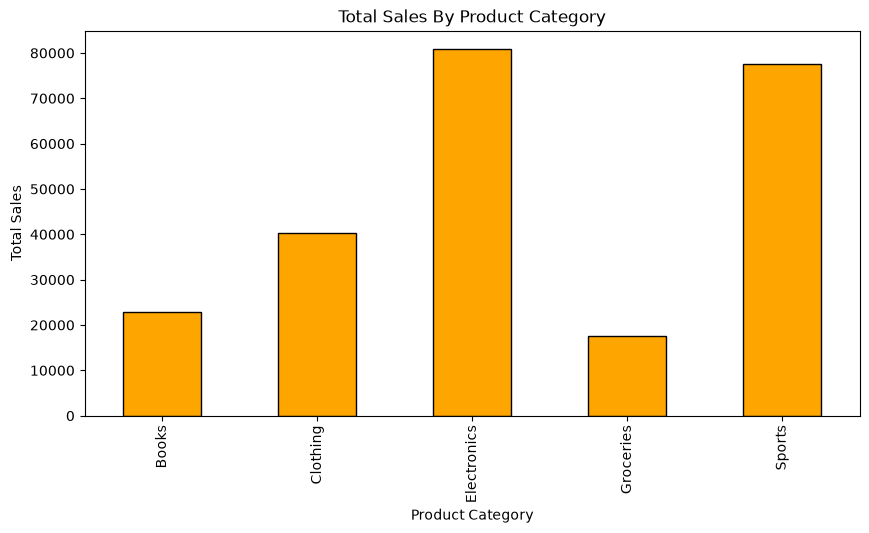

In [21]:
plt.figure(figsize=(10 , 5))

product_sales.plot(kind="bar" , color="orange" , edgecolor = "black")

plt.title("Total Sales By Product Category")

plt.xlabel("Product Category")

plt.ylabel("Total Sales")

plt.show()